# **Introduction to Spatial Domain Filters**

Spatial domain filters are essential in digital image processing, manipulating pixel intensities
within local neighborhoods to enhance images or extract features [1]. These filters are computationally efficient compared to frequency domain methods, making them ideal for real-time defense applications like surveillance and target recognition. This report, aligned with Digital
Image Processing, 4th Edition by Gonzalez and Woods, covers smoothing filters (Mean, Gaussian, Median, Bilateral) and edge detection/sharpening filters (Sobel, Prewitt, Laplacian, LoG, Unsharp Masking, High-Boost, Canny).

## **Why Necessary**
* Noise Reduction: Smoothing filters like Mean and Median enhance image clarity [1].

* Feature Extraction: Edge detection filters like Sobel and Canny highlight structural features [3].

* Image Enhancement: Sharpening filters improve visual quality [1].

* Preprocessing: Essential for segmentation and classification [2].

* Versatility: Applicable to binary, grayscale, and color images [1].

* Efficiency: Suitable for real-time processing [3].


## **What Are Spatial Domain Filters?**
<font color='green'>Spatial domain filters process pixel intensities using kernels or masks applied to local neighborhoods</font> [1]. A kernel defines weights or operations, controlling effects like smoothing or edge
detection. <font color='green'>They are classified as linear (e.g., Mean, Gaussian) or non-linear (e.g., Median, Canny)</font> [1]. Kernel size varies by application, e.g., larger for medical imaging noise reduction,
smaller for surveillance edge detection [3].

## **Types of Spatial Domain Filters**
<font color='green'>These filters use convolution or non-linear operations to process images [1].</font>
* Smoothing Filters
    * Mean Filter: Averages neighborhood intensities, effective for Gaussian noise.
    * Gaussian Filter: Uses a weighted Gaussian kernel, preserving edges.
    * Median Filter: Replaces pixels with neighborhood median, ideal for impulse noise.
    * Bilateral Filter: Combines spatial and intensity weighting, edge-preserving [2].
* Edge Detection and Sharpening Filters
    * Sobel Filter: Computes gradients for edge detection.
    * Prewitt Filter: Uses simpler kernels, less noise-robust.
    * Laplacian Filter: Highlights edges via second-order derivatives [1].
    * Laplacian of Gaussian (LoG) Filter: Combines Gaussian smoothing with Laplacian.
    * Unsharp Masking: Enhances edges by subtracting a blurred image.
    * High-Boost Filter: Amplifies original image with edges.
    * Canny Filter: Multi-stage edge detector [3].

# **Smoothing Filters**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

## **Mean Filter**

The Mean filter, also known as the Box filter, is a linear, low-pass spatial filter that smooths
an image by averaging pixel intensities within a local neighborhood. It operates in the spatial
domain through convolution, reducing high-frequency components (e.g., noise, edges) while preserving low-frequency components (e.g., smooth regions). Its simplicity makes it a cornerstone
for understanding more complex filtering techniques and a benchmark in research for evaluating
noise reduction, edge preservation, and computational efficiency.

From a research point of view, the Mean filter is studied for:
* Its role as a low-pass filter, analogous to frequency domain lowpass filtering.
* Its trade-offs between noise suppression and detail preservation.
* Its use as a preprocessing step in computer vision, medical imaging, and other applications.

cv2.filter2D is a built-in function in Python:
```python
    mean_kernel = np.ones((5,5), np.float32)/25
    mean_filtered = cv2.filter2D( img_gray , -1 , mean_kernel )
```

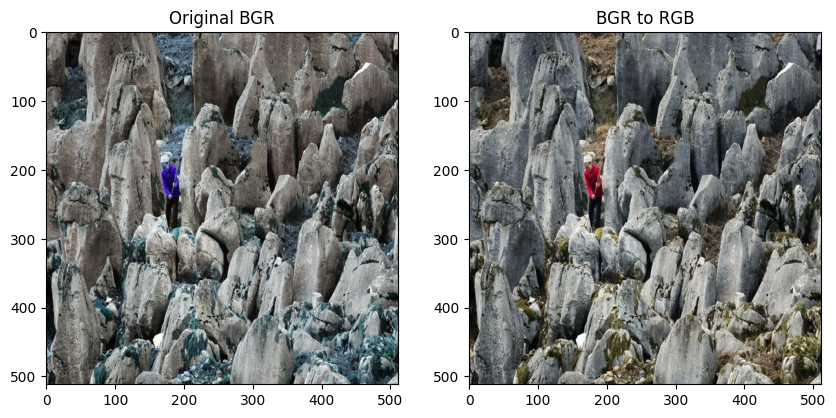

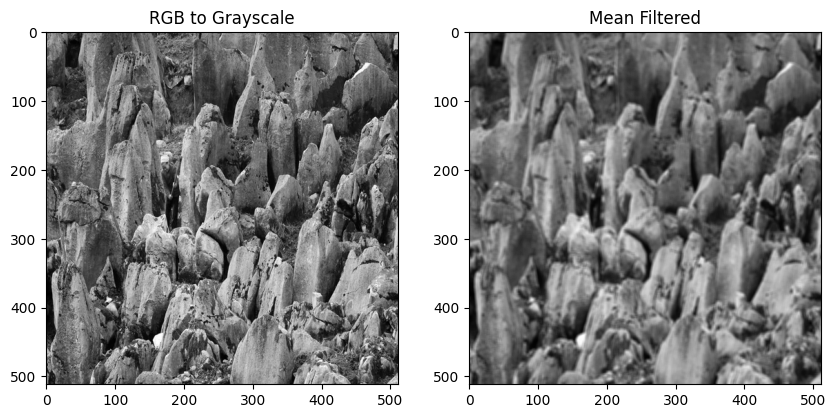

In [3]:
image_path = 'Env_Pack_512x512.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
mean_filtered = cv2.blur(img_gray, (5, 5))
os.makedirs('Mean_Filter', exist_ok=True)
cv2.imwrite('Mean_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Mean_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Mean_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Mean_Filter/mean_filtered.jpg', mean_filtered)
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img_bgr); plt.title('Original BGR')
plt.subplot(122); plt.imshow(img_rgb); plt.title('BGR to RGB')
plt.show()
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img_gray, cmap='gray'); plt.title('RGB to Grayscale')
plt.subplot(122); plt.imshow(mean_filtered, cmap='gray'); plt.title('Mean Filtered')
plt.show()

## **Gaussian Filter**
The Gaussian filter is a linear, low-pass spatial filter that smooths an image by applying a Gaussian-weighted kernel to pixel intensities in a local neighborhood. Unlike the Mean filter, it assigns higher weights to pixels closer to the center, reducing the blurring of edges while effectively suppressing noise. Its Gaussian kernel is derived from the Gaussian distribution, making it a critical tool in preprocessing for edge detection and computer vision tasks.

From a research point of view, the Gaussian filter is studied for:
* Its edge-preserving properties compared to other smoothing filters.
* Its role in multi-scale image analysis and feature extraction.
* Its application in noise reduction for medical imaging and surveillance.

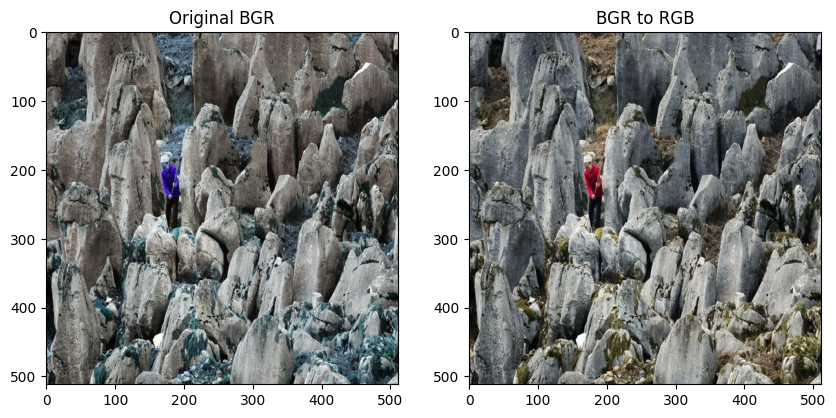

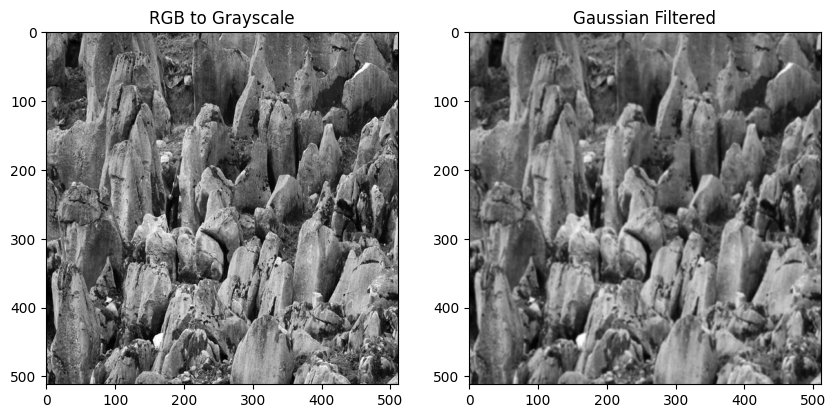

In [4]:
image_path = 'Env_Pack_512x512.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gaussian_filtered = cv2.GaussianBlur(img_gray, (5, 5), 0)
os.makedirs('Gaussian_Filter', exist_ok=True)
cv2.imwrite('Gaussian_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Gaussian_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Gaussian_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Gaussian_Filter/gaussian_filtered.jpg', gaussian_filtered)
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img_bgr); plt.title('Original BGR')
plt.subplot(122); plt.imshow(img_rgb); plt.title('BGR to RGB')
plt.show()
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img_gray, cmap='gray'); plt.title('RGB to Grayscale')
plt.subplot(122); plt.imshow(gaussian_filtered, cmap='gray'); plt.title('Gaussian Filtered')
plt.show()

## **Median Filter**
The Median filter is a non-linear, rank-order spatial filter that smooths an image by replacing
each pixel’s intensity with the median value of intensities in its neighborhood. It excels at
removing impulse noise (e.g., salt-and-pepper noise) while preserving edges, as it does not rely on averaging. This makes it a preferred choice in applications requiring robust noise reduction without compromising structural details.

From a research point of view, the Median filter is studied for:

* Its effectiveness against non-Gaussian noise compared to linear filters.
* Its edge-preserving properties in medical imaging and denoising tasks.
* Its computational complexity and optimization for real-time processing

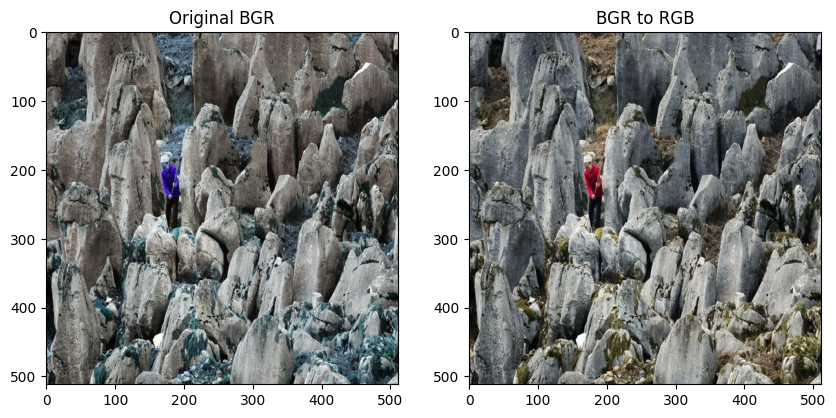

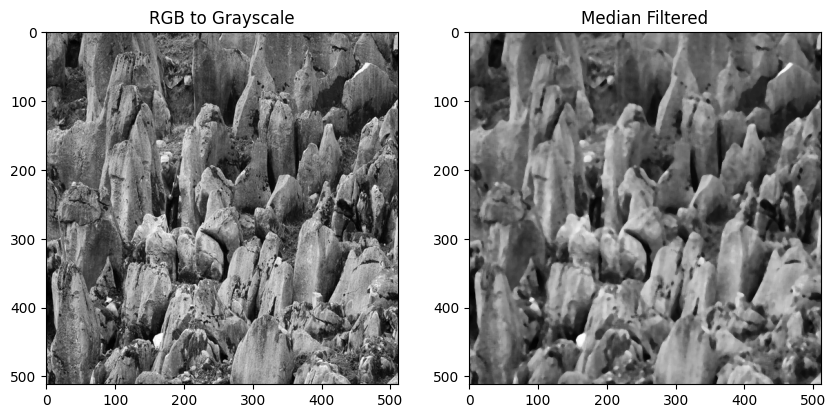

In [5]:
# MEDIAN FILTER CODE 
image_path = 'Env_Pack_512x512.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
median_filtered = cv2.medianBlur(img_gray, 5)
os.makedirs('Median_Filter', exist_ok=True)
cv2.imwrite('Median_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Median_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Median_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Median_Filter/median_filtered.jpg', median_filtered)
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img_bgr); plt.title('Original BGR')
plt.subplot(122); plt.imshow(img_rgb); plt.title('BGR to RGB')
plt.show()
plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(img_gray, cmap='gray'); plt.title('RGB to Grayscale')
plt.subplot(122); plt.imshow(median_filtered, cmap='gray'); plt.title('Median Filtered')
plt.show()

## **Bilateral Filter**
The Bilateral filter is a non-linear, edge-preserving spatial filter that smooths an image by combining spatial proximity and intensity similarity in its weighting scheme. It uses two Gaussian kernels—one for spatial distance and one for intensity difference—ensuring that only pixels with similar intensities contribute significantly. This makes it ideal for denoising while maintaining sharp edges in applications like surveillance and image enhancement.

From a research point of view, the Bilateral filter is studied for:
* Its ability to preserve edges while reducing noise, unlike linear filters.
* Its computational complexity and optimization for real-time applications.
* Its extensions in advanced denoising and texture analysis techniques

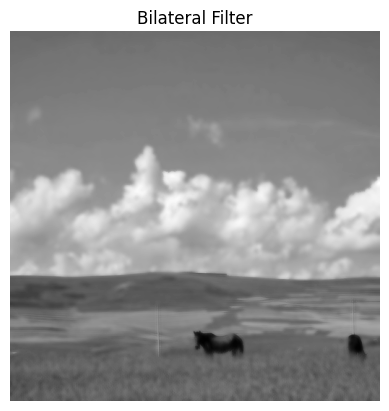

In [22]:
# BILATERAL FILTER CODE
image_path = 'Env_Pack_512x512(2).jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
bilateral_filtered = cv2.bilateralFilter(img_gray, 9, 75, 75)
os.makedirs('Bilateral_Filter', exist_ok=True)
cv2.imwrite('Bilateral_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Bilateral_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Bilateral_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Bilateral_Filter/bilateral_filtered.jpg', bilateral_filtered)
plt.imshow(bilateral_filtered, cmap='gray')
plt.title('Bilateral Filter')
plt.axis('off')
plt.show()

# **Edge Detection and Sharpening Filters**

## **Sobel Filter**
The Sobel filter is a linear, gradient-based spatial filter that detects edges by computing the intensity gradient of an image using two 3 × 3 kernels for horizontal and vertical directions. It approximates the first-order derivatives, highlighting regions of significant intensity change. Its
simplicity and effectiveness make it a standard tool for edge detection in real-time applications like surveillance.

From a research point of view, the Sobel filter is studied for:
* Its balance between edge detection accuracy and noise sensitivity.
* Its role in feature extraction for computer vision tasks.
* Its comparison with other gradient-based edge detectors like Prewitt.


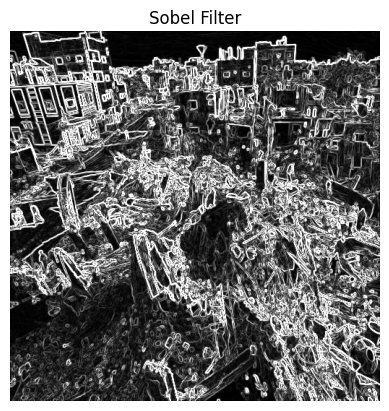

In [14]:
# SOBEL FILTER CODE
image_path = 'Env_Pack_512x512(1).jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)
sobel = np.clip(sobel, 0, 255).astype(np.uint8)
os.makedirs('Sobel_Filter', exist_ok=True)
cv2.imwrite('Sobel_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Sobel_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Sobel_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Sobel_Filter/sobel_filtered.jpg', sobel)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel Filter')
plt.axis('off')
plt.show()

## **Prewitt Filter**
The Prewitt filter is a linear, gradient-based spatial filter that detects edges using two 3 × 3 kernels to compute horizontal and vertical gradients. Similar to the Sobel filter, it highlightsintensity changes but uses equal weights in its kernels, making it simpler but less robust to
noise. It is suitable for low-noise images in basic edge detection tasks.

From a research point of view, the Prewitt filter is studied for:
* Its computational simplicity compared to other edge detectors.
* Its performance in low-noise environments.
* Its role as a baseline for evaluating advanced edge detection methods.

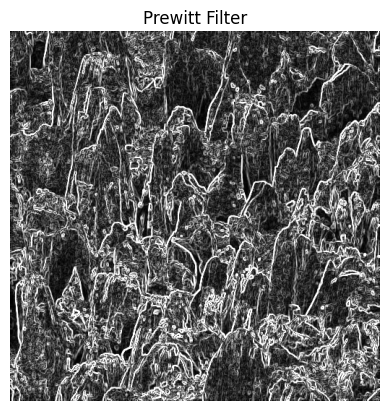

In [8]:
# PREWITT FILTER CODE
image_path = 'Env_Pack_512x512.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
prewitt_x = cv2.filter2D(img_gray, cv2.CV_64F, np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]))
prewitt_y = cv2.filter2D(img_gray, cv2.CV_64F, np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]))
prewitt = np.sqrt(prewitt_x**2 + prewitt_y**2)
prewitt = np.clip(prewitt, 0, 255).astype(np.uint8)
os.makedirs('Prewitt_Filter', exist_ok=True)
cv2.imwrite('Prewitt_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Prewitt_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Prewitt_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Prewitt_Filter/prewitt_filtered.jpg', prewitt)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt Filter')
plt.axis('off')
plt.show()

## **Laplacian Filter**
The Laplacian filter is a linear, second-order derivative spatial filter that detects edges by highlighting regions of rapid intensity change through the second derivative of the image. It produces a single output sensitive to edges in all directions but is highly susceptible to noise,
often requiring preprocessing. It is widely used in industrial inspection for detecting fine details.

From a research point of view, the Laplacian filter is studied for:
* Its sensitivity to noise and need for preprocessing.
* Its role in detecting fine edges and small features.
* Its integration with other filters for enhanced edge detection.

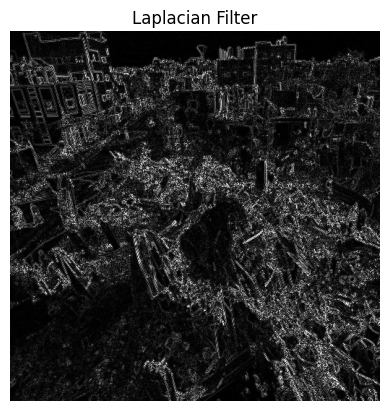

In [15]:
# LAPLACIAN FILTER CODE
image_path = 'Env_Pack_512x512(1).jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
laplacian = np.clip(np.abs(laplacian), 0, 255).astype(np.uint8)
os.makedirs('Laplacian_Filter', exist_ok=True)
cv2.imwrite('Laplacian_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Laplacian_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Laplacian_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Laplacian_Filter/laplacian_filtered.jpg', laplacian)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Filter')
plt.axis('off')
plt.show()

## **Laplacian of Gaussian (LoG) Filter**
The Laplacian of Gaussian (LoG) filter is a linear, second-order derivative spatial filter that combines Gaussian smoothing with the Laplacian to reduce noise sensitivity while detecting edges. By smoothing the image first, it emphasizes significant edges while suppressing noise,
making it suitable for medical imaging and object detection.

From a research point of view, the LoG filter is studied for:
* Its noise-robust edge detection capabilities.
* Its role in scale-space analysis and feature detection.
* Its application in preprocessing for complex vision tasks.

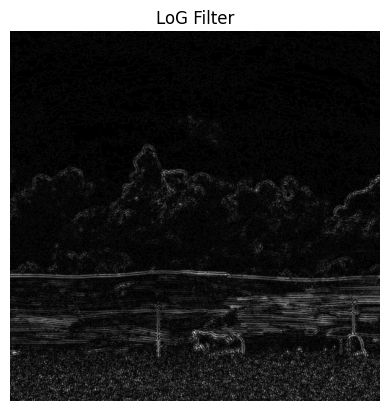

In [16]:
image_path = 'Env_Pack_512x512(2).jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
log = cv2.GaussianBlur(img_gray, (5, 5), 0)
log = cv2.Laplacian(log, cv2.CV_64F)
log = np.clip(np.abs(log), 0, 255).astype(np.uint8)
os.makedirs('LoG_Filter', exist_ok=True)
cv2.imwrite('LoG_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('LoG_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('LoG_Filter/grayscale.jpg', img_gray)
cv2.imwrite('LoG_Filter/log_filtered.jpg', log)
plt.imshow(log, cmap='gray')
plt.title('LoG Filter')
plt.axis('off')
plt.show()

## **Unsharp Masking**
Unsharp Masking is a linear, sharpening spatial filter that enhances edges by subtracting a blurred version of the image from the original and adding the result back with a scaling factor.This amplifies high-frequency components (edges), improving image clarity. It is widely used in photography and medical imaging for enhancing details.

From a research point of view, Unsharp Masking is studied for:
* Its ability to enhance edges without introducing significant artifacts.
* Its trade-offs between sharpness and noise amplification.
* Its role in image enhancement for visual inspection tasks.

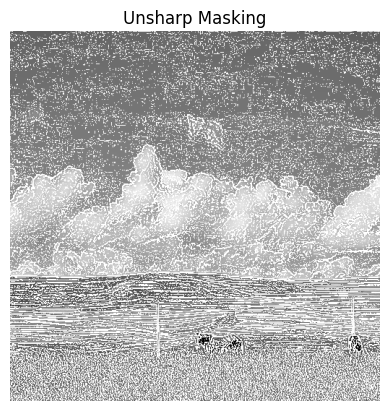

In [20]:
# USHARP MASKING CODE
image_path = 'Env_Pack_512x512(2).jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
unsharp = img_gray + 1.0 * (img_gray - cv2.GaussianBlur(img_gray, (5, 5), 0))
unsharp = np.clip(unsharp, 0, 255).astype(np.uint8)
os.makedirs('Unsharp_Masking', exist_ok=True)
cv2.imwrite('Unsharp_Masking/original_bgr.jpg', img_bgr)
cv2.imwrite('Unsharp_Masking/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Unsharp_Masking/grayscale.jpg', img_gray)
cv2.imwrite('Unsharp_Masking/unsharp_filtered.jpg', unsharp)
plt.imshow(unsharp, cmap='gray')
plt.title('Unsharp Masking')
plt.axis('off')
plt.show()

## **High-Boost Filter**
The High-Boost filter is a linear, sharpening spatial filter that extends Unsharp Masking by amplifying the original image with a stronger emphasis on high-frequency components (edges).
Using a scaling factor greater than 1, it enhances both edges and overall contrast, making it suitable for applications like satellite imagery requiring pronounced sharpness.

From a research point of view, the High-Boost filter is studied for:
* Its enhancement of both edges and low-frequency content.
* Its impact on image contrast and visual quality.
* Its comparison with other sharpening techniques.

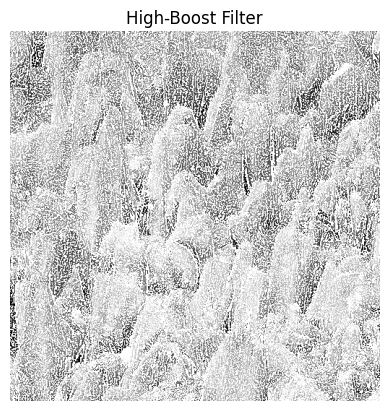

In [12]:
# HIGH-BOOST FILTER CODE
image_path = 'Env_Pack_512x512.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
high_boost = img_gray + 2.0 * (img_gray - cv2.GaussianBlur(img_gray, (5, 5), 0))
high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)
os.makedirs('High_Boost_Filter', exist_ok=True)
cv2.imwrite('High_Boost_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('High_Boost_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('High_Boost_Filter/grayscale.jpg', img_gray)
cv2.imwrite('High_Boost_Filter/high_boost_filtered.jpg', high_boost)
plt.imshow(high_boost, cmap='gray')
plt.title('High-Boost Filter')
plt.axis('off')
plt.show()

## **Canny Filter**
The Canny filter is a non-linear, multi-stage edge detection spatial filter that combines Gaussian smoothing, gradient computation, non-maximum suppression, and hysteresis thresholding. It provides robust edge detection by minimizing noise, accurately identifying edge directions, and
connecting weak edges to strong ones, making it a benchmark for edge detection in surveillance and computer vision.
From a research point of view, the Canny filter is studied for:
* Its robustness to noise and accuracy in edge localization.
* Its multi-stage approach as a model for advanced edge detectors.
* Its parameter optimization for specific applications.

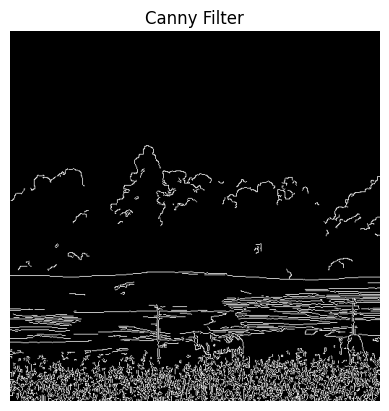

In [21]:
# CANNY FILTER CODE
image_path = 'Env_Pack_512x512(2).jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(img_gray, 100, 200)
os.makedirs('Canny_Filter', exist_ok=True)
cv2.imwrite('Canny_Filter/original_bgr.jpg', img_bgr)
cv2.imwrite('Canny_Filter/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Canny_Filter/grayscale.jpg', img_gray)
cv2.imwrite('Canny_Filter/canny_filtered.jpg', canny)
plt.imshow(canny, cmap='gray')
plt.title('Canny Filter')
plt.axis('off')
plt.show()

## **Practical Applications**
* `Medical Imaging`: Mean and Bilateral filters denoise MRI/ultrasound; Sobel and Canny
detect edges in X-rays [2].
* `Surveillance`: Canny and LoG identify objects in aerial imagery [3].
* `Computer Vision`: Median and Gaussian preprocess images for recognition [1].
* `Industrial Inspection`: Laplacian and Sobel detect manufacturing defects [1].

## **References**
[1] R. C. Gonzalez and R. E. Woods, Digital Image Processing, 4th ed. Pearson, 2018.

[2] C. Tomasi and R. Manduchi, “Bilateral filtering for gray and color images,” in Proc. IEEE Int. Conf. Comput. Vis., 1998, pp. 839–846.

[3] J. Canny, “A computational approach to edge detection,” IEEE Trans. Pattern Anal. Mach. Intell., vol. PAMI-8, no. 6, pp. 679–698, Nov. 1986.

[4] OpenCV, “OpenCV Documentation,” https://docs.opencv.org, 2025